IMPORT LIBRARY & MEMAHAMI DATASET

In [2]:
# Library Dasar Perhitungan
import numpy as np
import pandas as pd
import seaborn as sns

# Library Visualisasi Data
import matplotlib.pyplot as plt

# Library Machine Learning
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

In [3]:
# Load Dataset
data = pd.read_csv('CubanDataset.csv')

# Struktur Data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1697 entries, 0 to 1696
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1697 non-null   int64  
 1   age                1697 non-null   int64  
 2   menarche           1697 non-null   int64  
 3   menopause          1697 non-null   str    
 4   agefirst           1697 non-null   str    
 5   children           1697 non-null   str    
 6   breastfeeding      1697 non-null   str    
 7   nrelbc             1697 non-null   str    
 8   biopsies           1696 non-null   float64
 9   hyperplasia        1697 non-null   str    
 10  race               1697 non-null   str    
 11  year               1160 non-null   float64
 12  imc                1690 non-null   float64
 13  weight             1687 non-null   float64
 14  exercise           1697 non-null   str    
 15  alcohol            1697 non-null   str    
 16  tobacco            1697 non-null   

In [4]:
# Lihat 5 Data Teratas
data.head()

,id,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,hyperplasia,...,weight,exercise,alcohol,tobacco,allergies,emotional,depressive,histologicalclass,birads,cancer
0,1,50,11,No,No,0,No,Mother,1.0,Yes,...,83.4,No,Yes,Yes,Rhinitis,Sad,Yes,3.0,3A,Yes
1,2,46,12,No,36,1,3 months,Mother/Sister,2.0,Yes,...,78.2,2,Yes,No,Medicines,Joy,No,3.0,3B,Yes
2,3,47,13,No,26,1,3 months,Sister,1.0,Yes,...,82.6,1,No,Yes,Laryngitis,Sad,No,4.0,3B,Yes
3,4,49,11,47,21,1,No,Daughter,1.0,No,...,79.4,No,Yes,Yes,No,Joy,No,3.0,4B,Yes
4,5,54,14,42,16,1,1 month,Mother,2.0,Yes,...,81.5,No,Yes,No,No,Sad,Yes,4.0,3C,Yes


DATA CLEANING

In [5]:

# Ambil Variabel yang Berpengaruh pada Prediksi
selected_cols = ['age', 'menarche', 'menopause', 'agefirst', 'children', 'breastfeeding', 'nrelbc', 'biopsies', 'hyperplasia', 'race', 'imc', 'exercise', 'alcohol', 'tobacco', 'emotional', 'depressive', 'cancer']

data = data[selected_cols]
print("Variabel yang Dipilih")

# Cek Missing Value
print("\nMissing values:")
print(data.isnull().sum())

# Hapus Missing Data
data = data.dropna()

# Hapus Data Duplikat
data = data.drop_duplicates()
print("\nDuplicated values:")
print(data.duplicated().sum())

Variabel yang Dipilih

Missing values:
age              0
menarche         0
menopause        0
agefirst         0
children         0
breastfeeding    0
nrelbc           0
biopsies         1
hyperplasia      0
race             0
imc              7
exercise         0
alcohol          0
tobacco          0
emotional        0
depressive       0
cancer           0
dtype: int64

Duplicated values:
0


ANALISIS DESKRIPTIF

In [6]:
# Kelompokan Kolom Numerik
numeric_cols = ['age', 'menarche', 'biopsies', 'imc']

# Melakukan Analisis Deskriptif
descriptive_stats = pd.DataFrame(index=numeric_cols, columns=['Mean', 'Median', 'Mode', 'Variance', 'Standar_Deviasi'])

for col in numeric_cols:
    descriptive_stats.loc[col, 'Mean'] = data[col].mean()
    descriptive_stats.loc[col, 'Median'] = data[col].median()
    descriptive_stats.loc[col, 'Mode'] = data[col].mode()[0]
    descriptive_stats.loc[col, 'Variance'] = data[col].var()
    descriptive_stats.loc[col, 'Standar_Deviasi'] = data[col].std()

print(descriptive_stats)

               Mean Median  Mode    Variance Standar_Deviasi
age       51.516014   53.0    54  142.334165       11.930388
menarche  11.715896   12.0    11    3.378584        1.838092
biopsies   1.314947    1.0   1.0    1.402827         1.18441
imc       25.534935   25.1  24.5   24.658607        4.965743


ENCODING DATA

In [7]:
# Data Yes / No
binary_cols = [
    'hyperplasia',
    'alcohol',
    'tobacco',
    'depressive',
    'cancer'
]

binary_map = {'Yes': 1, 'No': 0}

for col in binary_cols:
    data[col] = data[col].replace(binary_map)

# Encoding Breastfeeding
def breastfeeding_duration(x):
    if pd.isna(x):
        return 0
    x = str(x).strip().lower()
    if x == 'no':
        return 0
    if 'month' in x:
        return int(x.split()[0])
    if x.isdigit():
        return int(x)
    return 0

data['breastfeeding'] = data['breastfeeding'].apply(breastfeeding_duration)
data['breastfeeding'] = data['breastfeeding'].astype(int)

# Encoding Exercise
data['exercise'] = (data['exercise'].replace({'No': 0, 'NO': 0,'Diary': 7}))

# # Encoding Emotional
data['emotional'] = data['emotional'].replace({'Sad': 0, 'Joy': 1})

# # Encoding Menopause
data['menopause'] = data['menopause'].replace({'No': 0, '0': 0})
data['menopause'] = data['menopause'].astype(int)
data['menopause'] = data['menopause'].apply(lambda x: 0 if x == 0 else 1)

# Encoding Agefirst
data['agefirst'] = data['agefirst'].replace({'No': 0, '0': 0})
data['agefirst'] = data['agefirst'].astype(int)
data['agefirst'] = data['agefirst'].apply(lambda x: 0 if x == 0 else 1)

# Encoding NRELBC
def encode_nrelbc(x):
    if x == 'No':
        return 0
    elif isinstance(x, str):
        return len(x.split('/'))
    else:
        return x

data['nrelbc'] = data['nrelbc'].apply(encode_nrelbc)

# Encoding Biopsies
data['biopsies'] = data['biopsies'].fillna(0).astype(int)

# Encoding Race
data = pd.get_dummies(data, columns=['race'], drop_first=True)
race_cols = ['race_Mixed', 'race_White']
data[race_cols] = data[race_cols].astype(int)

# Encoding Children
data['children'] = data['children'].replace('5+', 6).astype(int)

print(data['breastfeeding'].unique())
data.head()

[ 0  3  1  2  4  8  6  5  7 10  9 12 11 18 16 36 15 72 13 24 48 14 17 22
 26 25 28 21]


,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,hyperplasia,imc,exercise,alcohol,tobacco,emotional,depressive,cancer,race_Mixed,race_White
0,50,11,0,0,0,0,1,1,1,27.6,0,1,1,0,1,1,0,1
1,46,12,0,1,1,3,2,2,1,27.3,2,1,0,1,0,1,1,0
2,47,13,0,1,1,3,1,1,1,24.6,1,0,1,0,0,1,0,0
3,49,11,1,1,1,0,1,1,0,28.6,0,1,1,1,0,1,0,0
4,54,14,1,1,1,1,1,2,1,28.4,0,1,0,0,1,1,0,1


In [8]:
data.isna().sum()

age              0
menarche         0
menopause        0
agefirst         0
children         0
breastfeeding    0
nrelbc           0
biopsies         0
hyperplasia      0
imc              0
exercise         0
alcohol          0
tobacco          0
emotional        0
depressive       0
cancer           0
race_Mixed       0
race_White       0
dtype: int64

In [9]:
# Statistik Singkat
data.describe()

,age,menarche,menopause,agefirst,children,breastfeeding,nrelbc,biopsies,imc,race_Mixed,race_White
count,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000,1686.000000
mean,51.516014,11.715896,0.629893,0.708185,0.995255,3.258600,0.666667,1.314947,25.534935,0.320878,0.427639
std,11.930388,1.838092,0.482976,0.454732,0.927638,5.544706,0.718004,1.184410,4.965743,0.466952,0.494883
min,20.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,45.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.800000,0.000000,0.000000
50%,53.000000,12.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,25.100000,0.000000,0.000000
75%,61.000000,13.000000,1.000000,1.000000,2.000000,5.000000,1.000000,2.000000,27.300000,1.000000,1.000000
max,90.000000,17.000000,1.000000,1.000000,6.000000,72.000000,4.000000,5.000000,88.800000,1.000000,1.000000


EDA MENDALAM

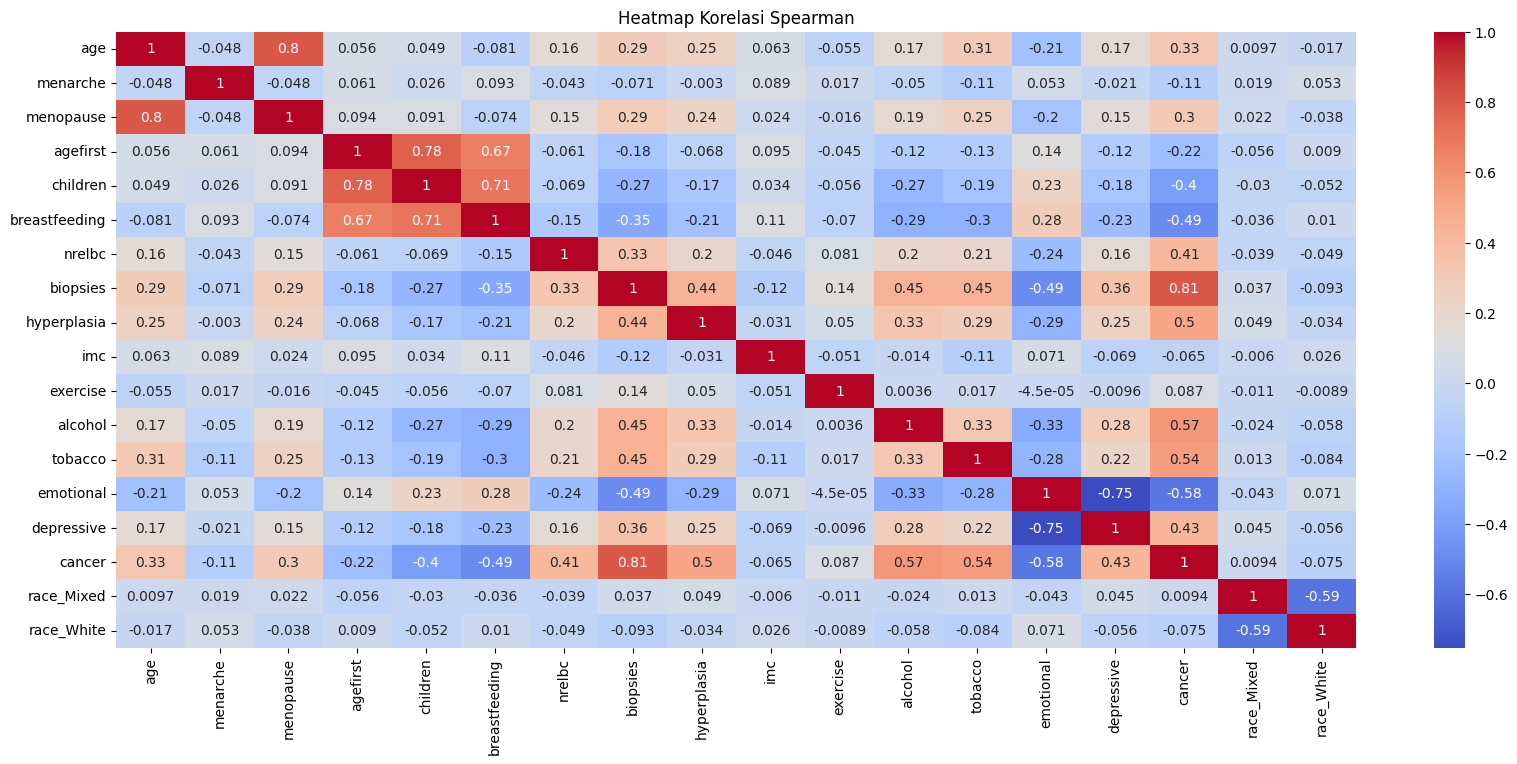

In [10]:
corr_pearson = data.corr(method='pearson')
corr_spearman = data.corr(method='spearman')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.heatmap(corr_spearman, cmap='coolwarm', annot=True)
plt.title('Heatmap Korelasi Spearman')
plt.show()

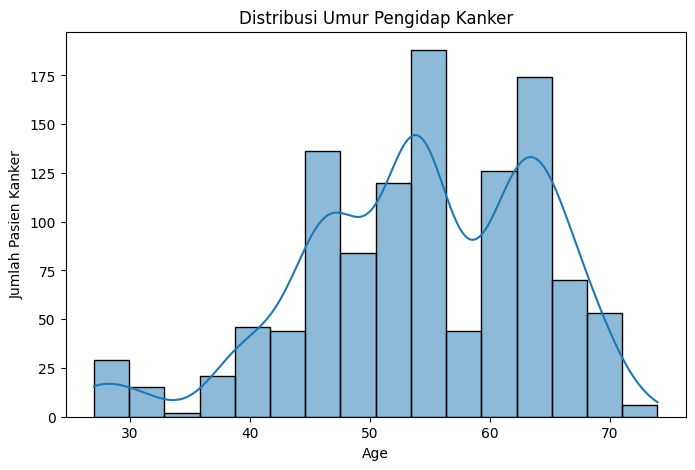

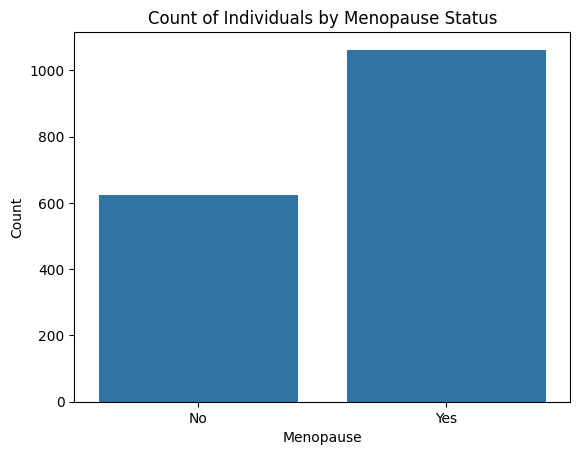

C:\Users\Raihan Daniswara\AppData\Local\Temp\ipykernel_16672\2597654780.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cancer', y='age', data=data, palette=['skyblue','salmon'])


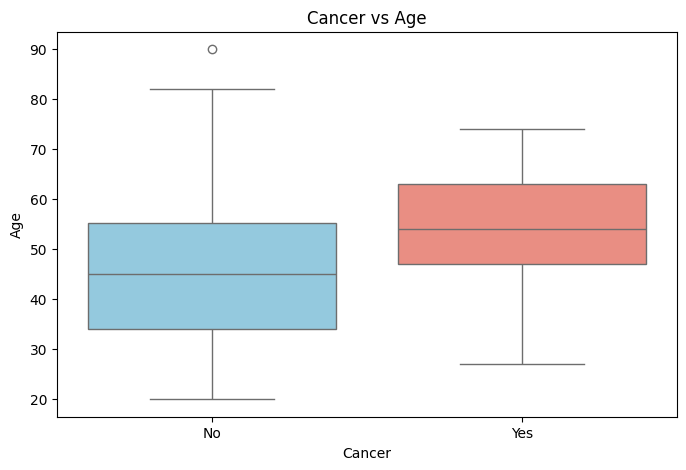

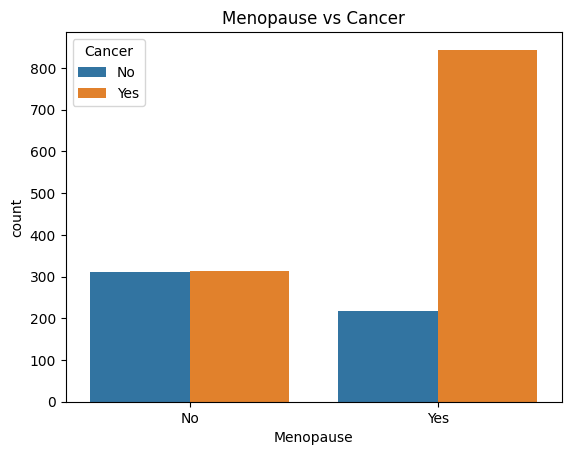

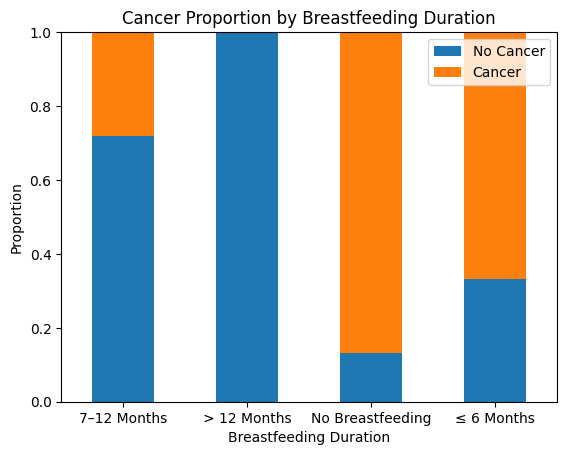

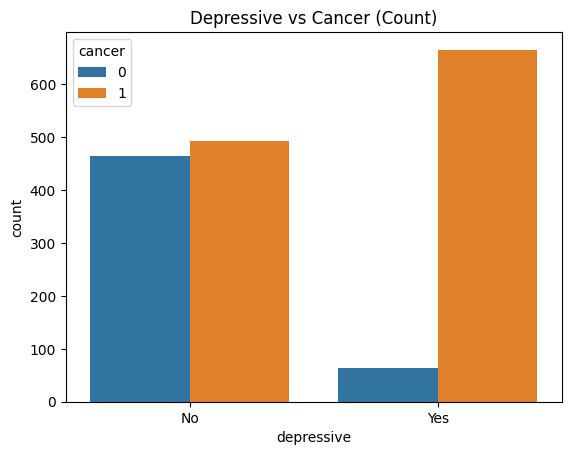

In [11]:
# Filter pengidap kanker
cancer_patients = data[data['cancer'] == 1]

# Histogram umur
plt.figure(figsize=(8,5))
sns.histplot(cancer_patients['age'], kde=True)
plt.title("Distribusi Umur Pengidap Kanker")
plt.xlabel("Age")
plt.ylabel("Jumlah Pasien Kanker")
plt.show()

# Countplot Menopause
sns.countplot(x='menopause', data=data)
plt.title('Count of Individuals by Menopause Status')
plt.xlabel('Menopause')
plt.xticks([0,1], ['No', 'Yes'])
plt.ylabel('Count')
plt.show()

# Boxplot Cancer vs Age
plt.figure(figsize=(8,5))
sns.boxplot(x='cancer', y='age', data=data, palette=['skyblue','salmon'])
plt.title("Cancer vs Age")
plt.xlabel("Cancer")
plt.ylabel("Age")
plt.xticks([0,1], ['No', 'Yes'])
plt.show()


# Countplot Cancer vs Menopouse
ax = sns.countplot(x='menopause', hue='cancer', data=data)
plt.title('Menopause vs Cancer')
plt.xticks([0,1], ['No', 'Yes'])
plt.xlabel('Menopause')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No', 'Yes'], title='Cancer')
plt.show()

# Crosstab Breastfeeding vs Cancer
def bf_group(x):
    if x == 0:
        return 'No Breastfeeding'
    elif x <= 6:
        return '≤ 6 Months'
    elif x <= 12:
        return '7–12 Months'
    else:
        return '> 12 Months'

bf_group_series = data['breastfeeding'].apply(bf_group)

ct = pd.crosstab(
    bf_group_series,
    data['cancer'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True)
plt.title('Cancer Proportion by Breastfeeding Duration')
plt.xlabel('Breastfeeding Duration')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Cancer', 'Cancer'])
plt.show()

# Countplot Depressive vs Cancer
sns.countplot(x='depressive', hue='cancer', data=data)
plt.title('Depressive vs Cancer (Count)')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()


PEMODELAN MACHINE LEARNING

In [12]:
# Pisahkan Fitur dan target
x = data.drop('cancer', axis=1)
y = data['cancer']

In [13]:
# Inisialisasi Stratified 5-Fold (Untuk 5 Fold Validation)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inisialisasi Random Forest
model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, class_weight='balanced')
cv_scores = cross_val_score(model, x, y, cv=skf, scoring='accuracy')
roc_scores = cross_val_score(model, x, y, cv=skf, scoring='roc_auc')

# Hasil Evaluasi
print("Akurasi tiap fold :", cv_scores)
print("Rata-rata Akurasi :", np.mean(cv_scores))
print("Rata-rata ROC AUC :", np.mean(roc_scores))
print("Standar Deviasi   :", np.std(cv_scores))
y_pred = cross_val_predict(model, x, y, cv=skf)
print("\nClassification Report:")
print(classification_report(y, y_pred))

ValueError: Supported target types are: ('binary', 'multiclass'). Got 'unknown' instead.

          feature  importance
7        biopsies    0.423673
13      emotional    0.138416
11        alcohol    0.084136
12        tobacco    0.079018
8     hyperplasia    0.070629
5   breastfeeding    0.053417
0             age    0.028858
6          nrelbc    0.027314
4        children    0.023414
14     depressive    0.022246
9             imc    0.022135
1        menarche    0.009415
2       menopause    0.006047
10       exercise    0.005153
16     race_White    0.002551
3        agefirst    0.002283
15     race_Mixed    0.001294


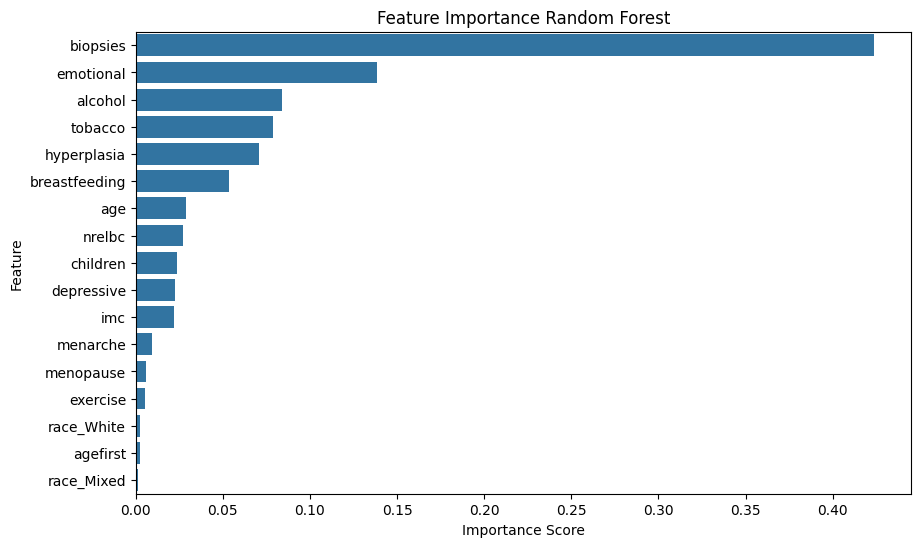

In [ ]:
model.fit(x, y)
feature_importance = pd.DataFrame({
    "feature": x.columns,
    "importance": model.feature_importances_
})
print(feature_importance.sort_values(by="importance", ascending=False))

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.sort_values(by="importance", ascending=False)
)
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()